In [76]:
from spin_lattices import KagomeLattice, SpinLattice, SquareLattice, TriangleLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from fast_boolean_analysis import (
    keep_largest_n,
    keep_everything,
    ScorerType,
    get_scorer,
    FourierSeries,
    fourier_expand,
)
from lattice_boolean_analysis import (
    AmplitudeMedianBinSignalKind,
    SignSignalKind,
    AmplitudeSignalKind,
    SignalKind,
    LBFFromSpinSystem,
)
from loguru import logger

from pathlib import Path
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import matplotlib.pyplot as plt
from itertools import product
import numpy.typing as npt
from tqdm import tqdm
import seaborn as sns
import parse
import sys
from typing import NamedTuple

from parity import popcount
from dataclasses import dataclass, astuple

ground_state_cache_dir = Path("groundstates")


def total_hamming_weight(series: FourierSeries, terms: int) -> int:
    popcounts = popcount(np.asarray(np.argpartition(series.coeffs, -terms)[-terms:]))
    inv_popcounts = series.signal.number_spins - popcounts
    return np.sum(np.minimum(popcounts, inv_popcounts))


def get_score_column(df: pd.DataFrame, scorer: str) -> list:
    return [
        row["series"].truncate(keep_largest_n(row["terms"])).prediction_score(scorer=scorer)
        for _, row in (df.iterrows())
    ]

logger.remove()
logger.add(Path("boolean-analysis-complexity.log", level="DEBUG"))


3

In [2]:
%matplotlib inline

In [77]:
class LatticeOptions(NamedTuple):
    lattice: SpinLattice
    use_symmetries: bool
    max_terms: int | None

In [78]:
# lattice_opts = [
#     LatticeOptions(lattice=SquareLattice(width=4, height=4), use_symmetries=True, max_terms=None),
#     LatticeOptions(lattice=SquareLattice(width=4, height=5), use_symmetries=False, max_terms=2 ** 11),
#     LatticeOptions(lattice=SquareLattice(width=4, height=6), use_symmetries=True, max_terms=2 ** 15),
# ]
lattice_opts = [
    LatticeOptions(TriangleLattice(width=4, height=4), use_symmetries=True, max_terms=None),
#   LatticeOptions(TriangleLattice(width=4, height=5), use_symmetries=False, max_terms=2 ** 11),
#    LatticeOptions(TriangleLattice(width=4, height=6), use_symmetries=True, max_terms=2 ** 15),
]
name_to_lattice_opt = {lattice.lattice.get_cache_id(): lattice for lattice in lattice_opts}


In [79]:
%matplotlib widget

In [80]:
J2s = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
signal_kinds = [SignSignalKind(), AmplitudeMedianBinSignalKind()]

In [82]:
all_series: dict[tuple[str, float, str], FourierSeries] = {}

for (lattice_opt, J2, signal_kind) in product(lattice_opts, J2s, signal_kinds):
    lattice, use_symmetries, max_terms = lattice_opt
    system=HeisenbergJ1J2(
                lattice=lattice,
                J1=1,
                J2=J2,
                use_symmetries=use_symmetries,
                spin_inversion=1 if use_symmetries else None,
                ground_state_cache_dir=ground_state_cache_dir,
    )
    system.get_eigenstates(1)
    series = fourier_expand(LBFFromSpinSystem(system=system, eigenstate=0, kind=signal_kind))
    all_series[lattice.get_cache_id(), J2, signal_kind.name] = series


In [84]:
scorers = ["sign_overlap", "accuracy", "f1"]
target_score = 0.8
target_scorer = "accuracy"

rows = []

for (lattice_name, J2, signal_kind), series in all_series.items():
    lattice, use_symmetries, max_terms = name_to_lattice_opt[lattice_name]

    success, how_many_terms, prediction = series.how_many_terms_to_achieve_score(
        target_score, scorer=target_scorer, max_terms=max_terms, orbitwise=False
    )
    scores = {
        scorer: series.truncate(
            keep_largest_n(how_many_terms)
        ).prediction_score(scorer=scorer, prediction=prediction)[0]
        for scorer in scorers
    }
    rows.append(
        {
            "lattice_name": lattice_name,
            "J2": J2,
            "signal_kind": signal_kind,
            "series": series,
            "success": success,
            "terms": how_many_terms,
        }
        | scores
    )
    print(rows[-1])


{'lattice_name': 'TriangleLattice4x4', 'J2': 0.0, 'signal_kind': 'sign', 'series': <fast_boolean_analysis.FourierSeries object at 0x14f59a32c070>, 'success': True, 'terms': 1, 'sign_overlap': 1.0, 'accuracy': 1.0, 'f1': 1.0}
{'lattice_name': 'TriangleLattice4x4', 'J2': 0.0, 'signal_kind': 'amplitude_median_bin', 'series': <fast_boolean_analysis.FourierSeries object at 0x14f597e2f520>, 'success': True, 'terms': 73, 'sign_overlap': 0.949205768518137, 'accuracy': 0.8343434343434344, 'f1': 0.8577325261419922}
{'lattice_name': 'TriangleLattice4x4', 'J2': 0.1, 'signal_kind': 'sign', 'series': <fast_boolean_analysis.FourierSeries object at 0x14f597ea4b20>, 'success': True, 'terms': 1, 'sign_overlap': 1.0, 'accuracy': 1.0, 'f1': 1.0}
{'lattice_name': 'TriangleLattice4x4', 'J2': 0.1, 'signal_kind': 'amplitude_median_bin', 'series': <fast_boolean_analysis.FourierSeries object at 0x14f597ea7a30>, 'success': True, 'terms': 83, 'sign_overlap': 0.9567277326668563, 'accuracy': 0.8351204351204351, 'f1

In [85]:
series_df = (
    pd.DataFrame(rows)
    .assign(
        hamming_weight=lambda df: df.apply(
            lambda row: total_hamming_weight(row["series"], row["terms"]), axis=1
        ),
        number_spins=lambda df: df["series"].apply(lambda a: a.signal.number_spins),
    )
    .assign(
        mean_hw=lambda df: df["hamming_weight"] / df["terms"],
    )
    .set_index(["lattice_name", "J2", "signal_kind"])
)


In [86]:
series_df.groupby('lattice_name')['terms'].max()

lattice_name
TriangleLattice4x4    238
Name: terms, dtype: int64

In [87]:
(series_df['success'] == True).all()

True

In [88]:
%matplotlib inline

In [89]:
series_df.query('success == False')

,,,series,success,terms,sign_overlap,accuracy,f1,hamming_weight,number_spins,mean_hw
lattice_name,J2,signal_kind,,,,,,,,,


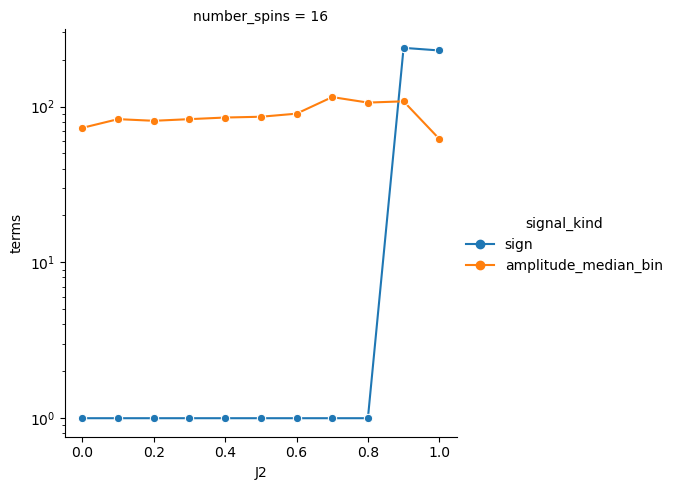

In [90]:
sns.relplot(
    series_df,
    x="J2",
    y="terms",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    # markers=True,
    style="signal_kind",
    dashes=False,
    markers=["o", "o"],
    # make y axis independent
    # facet_kws=dict(sharey=False),
).set(yscale="log")


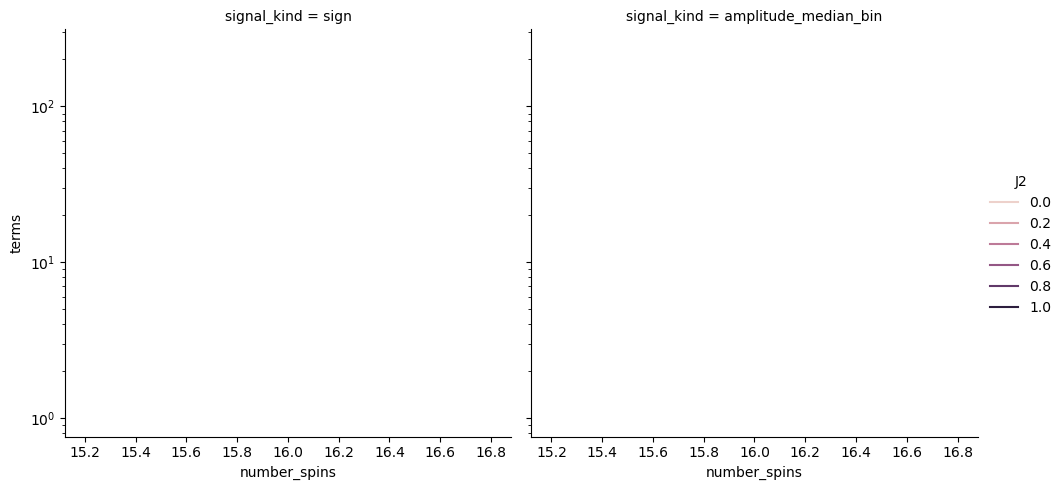

In [15]:
sns.relplot(
    series_df.reset_index(),
    # .assign(J2=lambda df: df["J2"].astype(str)),
    x="number_spins",
    y="terms",
    col="signal_kind",
    hue="J2",
    kind="line",
    markers=True,
).set(yscale="log")


In [91]:
def plot_subsets(subsets, titles, lat: SpinLattice):
    fig, axes = plt.subplots(1, len(subsets), figsize=(len(subsets) * 3, 3), squeeze=False)
    for ax, subset, title in zip(axes[0], subsets, titles):
        lat.plot(spins=subset, ax=ax)
        ax.axis("off")
        ax.set_title(title)
    return fig


In [92]:
def get_abslargest_terms(coeffs: npt.NDArray, n: int) -> tuple[npt.NDArray[np.uint64], npt.NDArray]:
    """Get the n largest terms in absolute value."""
    abs_values = np.abs(coeffs)
    indices = np.asarray(np.argpartition(abs_values, -n)[-n:], dtype=np.uint64)
    sorted_indices = indices[np.argsort(-abs_values[indices])]
    return sorted_indices, coeffs[sorted_indices]


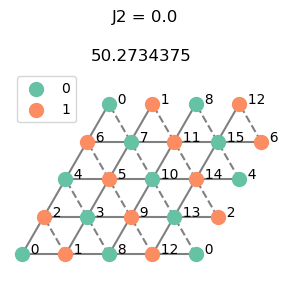

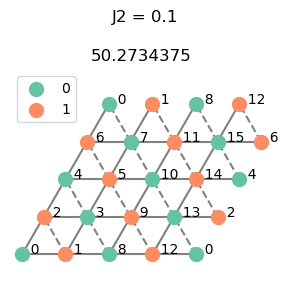

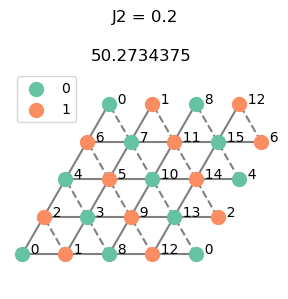

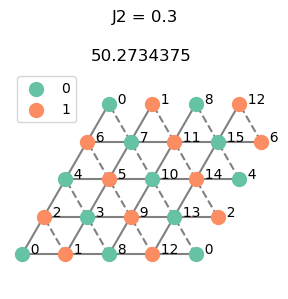

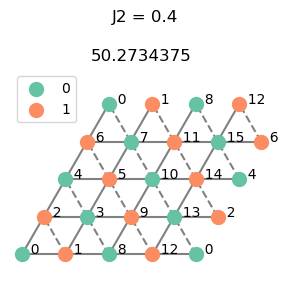

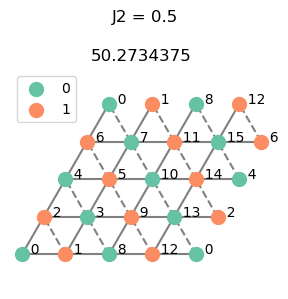

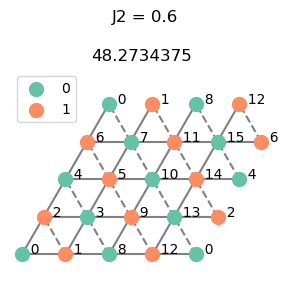

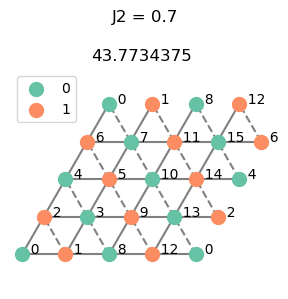

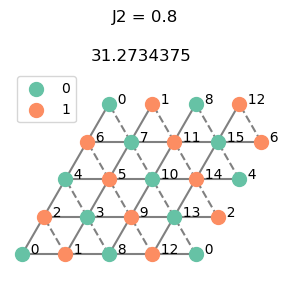

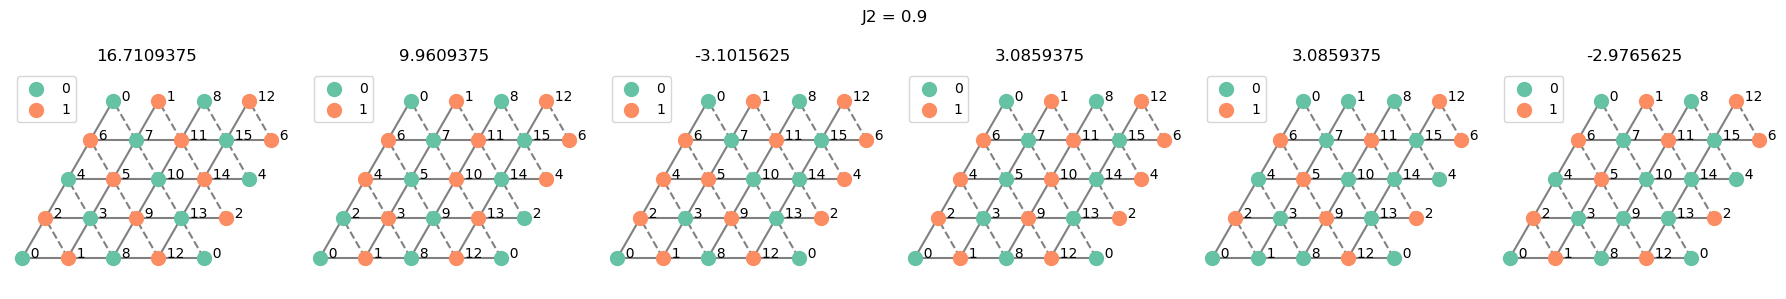

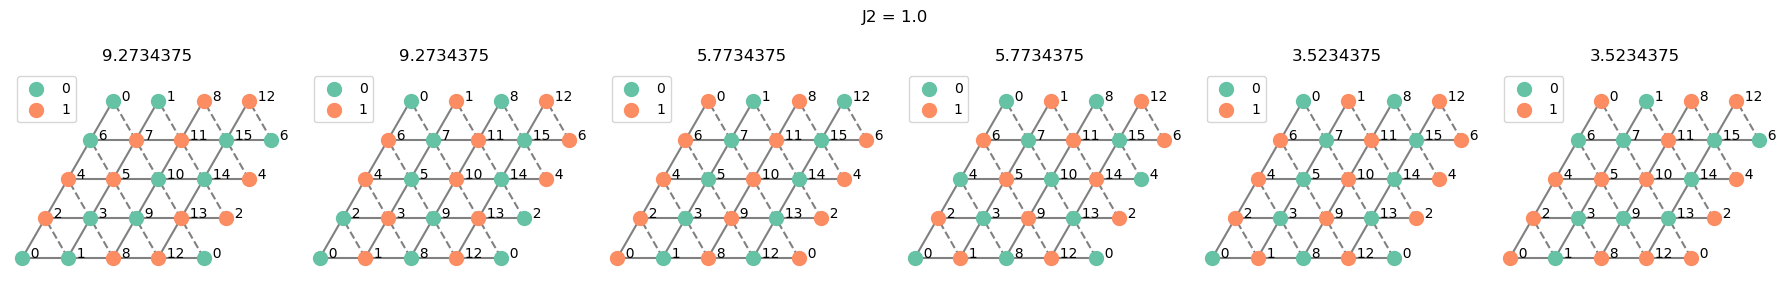

In [96]:
lattice_name = 'TriangleLattice4x4'
# signal = "amplitude_median_bin"
max_subsets = 6
signal = "sign"
for J2, row in (
    series_df.sort_index(level="J2")
    .xs((lattice_name, signal), level=("lattice_name", "signal_kind"))
    .iterrows()
):
    series = row['series']
    coeffs = series.coeffs
    reprs = series.signal.lattice.get_fourier_repr().reprs
    coeffs_reprs = np.zeros_like(coeffs)
    coeffs_reprs[reprs] = coeffs[reprs]
    
    subsets, coeffs = get_abslargest_terms(coeffs_reprs, min(max_subsets, row["terms"]))
    fig = plot_subsets(subsets, coeffs, row["series"].signal.lattice)
    fig.suptitle(f"J2 = {J2}")
    fig.tight_layout()
    fig.show()



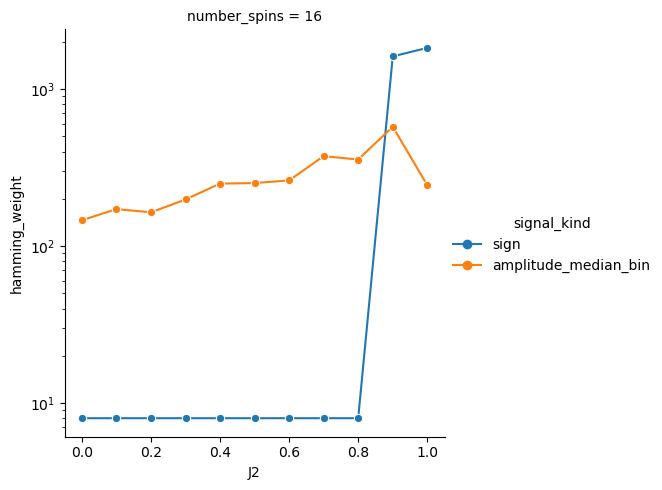

In [94]:
sns.relplot(
    series_df,
    x="J2",
    y="hamming_weight",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    style="signal_kind",
    dashes=False,
    facet_kws=dict(sharex=True),
    markers=["o", "o"],
).set(yscale="log")


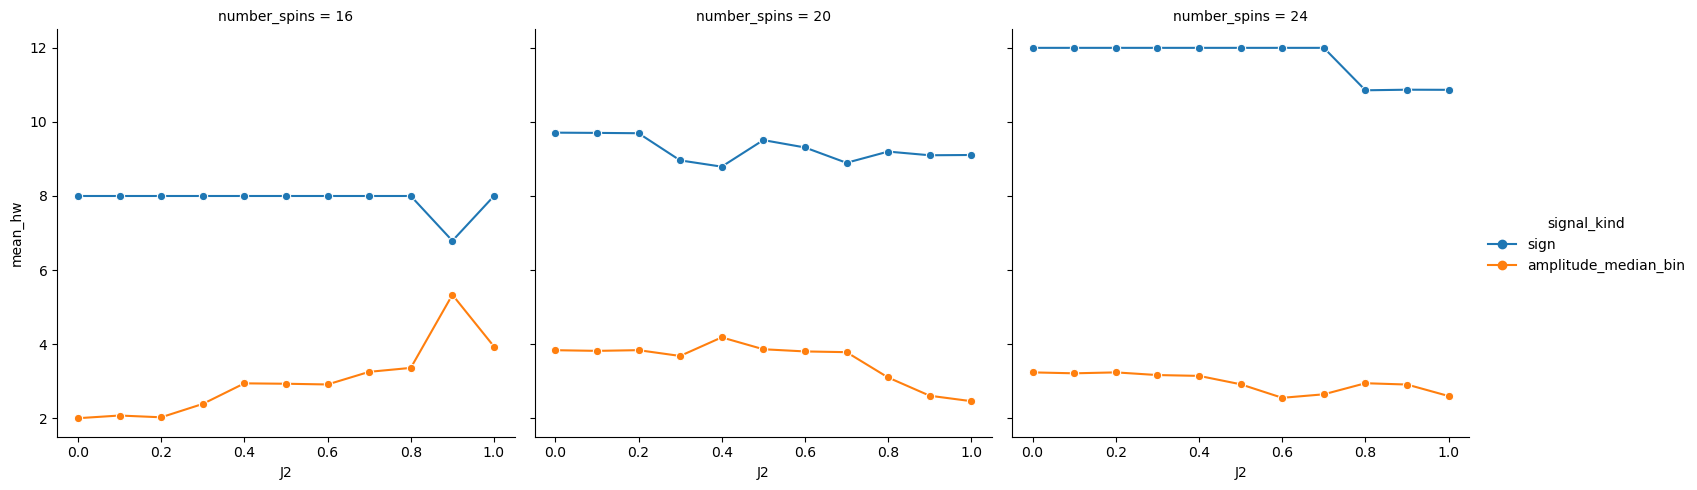

In [24]:
sns.relplot(
    series_df,
    x="J2",
    y="mean_hw",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


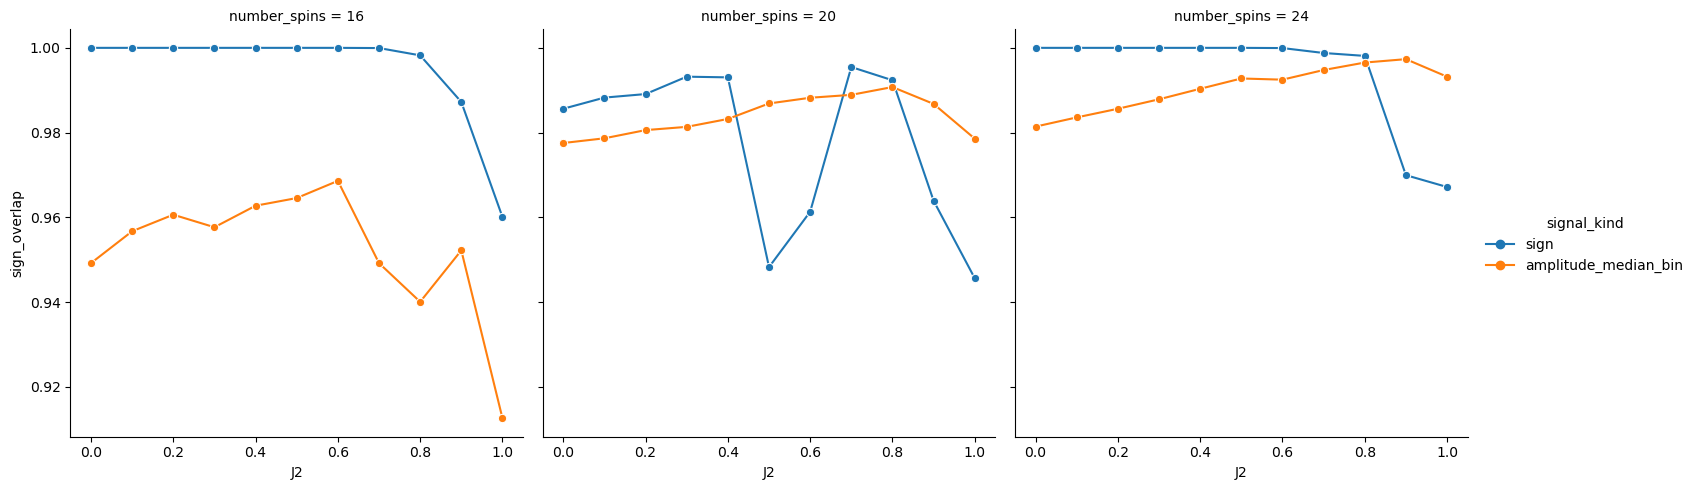

In [29]:
sns.relplot(
    series_df,
    x="J2",
    y="sign_overlap",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


In [26]:
complexity_ratio_df = (
    series_df.unstack(level="signal_kind")["hamming_weight"]
    .assign(ratio=lambda df: df["sign"] / df["amplitude_median_bin"])
    .reset_index()
)


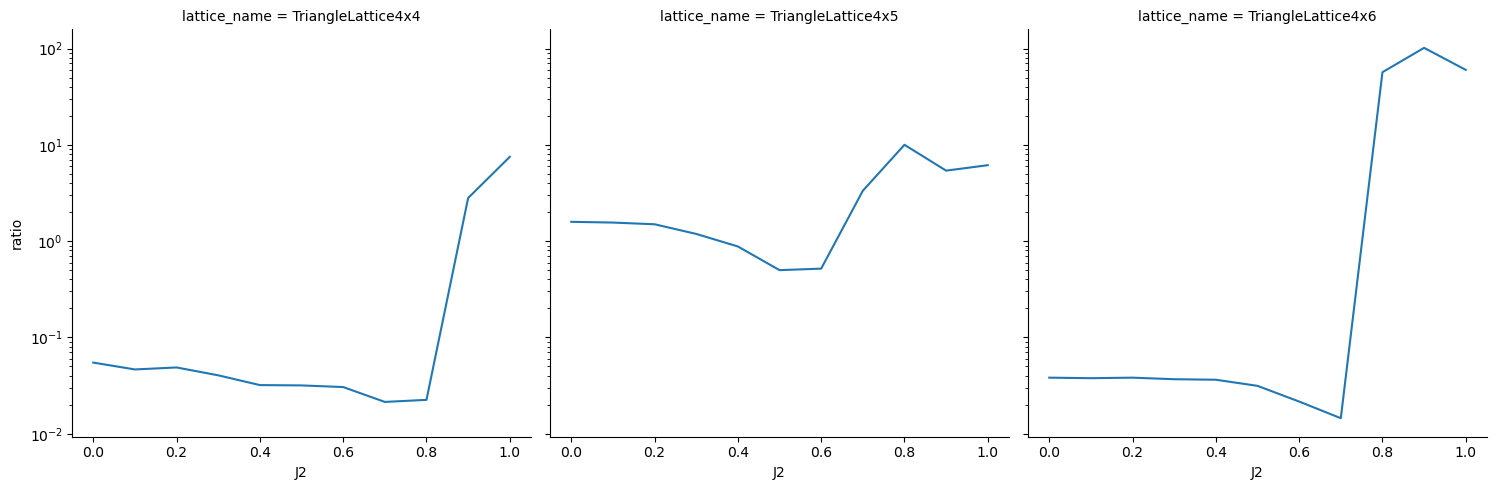

In [27]:
sns.relplot(complexity_ratio_df, x="J2", y="ratio", col="lattice_name", kind="line").set(yscale="log")


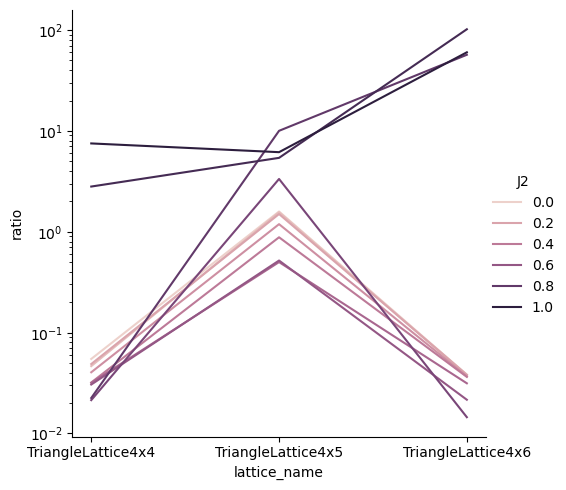

In [28]:
sns.relplot(
    complexity_ratio_df,
    x="lattice_name",
    y="ratio",
    hue="J2",
    kind="line",
).set(yscale="log")
